# COMP 541 Final Project: Instacart Snack Department Analysis

This notebook analyzes the Snacks department in the Instacart dataset using statistical analysis and pattern mining. The goal is to find insights that go beyond common-sense within-department purchasing behavior.

# Loading Dataset (Spencer)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets from Google Drive folder
department_df = pd.read_csv('data/departments.csv')
orders_df = pd.read_csv('data/orders.csv')
products_df = pd.read_csv('data/products.csv')
order_products_train_df = pd.read_csv('data/order_products__train.csv')
aisles_df = pd.read_csv('data/aisles.csv')

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Preview Datasets (Spencer)

In [42]:
print("departments_df")
display(department_df.head())

print("orders_df")
display(orders_df.head())

print("products_df")
display(products_df.head())

print("order_products_train_df")
display(order_products_train_df.head())

print("aisles_df")
display(aisles_df.head())

departments_df


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


orders_df


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


products_df


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


order_products_train_df


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


aisles_df


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


# Statistical Analyses

## Statistical Analysis 1: Snack Department Overview and Top Products

In [43]:
# Total number of snack products (Department Overview)
snack_department = 19
snack_count = (products_df['department_id'] == snack_department).sum()
print(snack_count)

6264


In [44]:
# Most commonly bought snacks (Top Products)
snack_products = products_df[products_df['department_id'] == snack_department]
snack_orders = order_products_train_df.merge(snack_products, on='product_id')
top_snacks = snack_orders['product_name'].value_counts().head(10)
print(top_snacks)

product_name
Lightly Salted Baked Snap Pea Crisps                   991
Pretzel Crisps Original Deli Style Pretzel Crackers    753
Sea Salt Pita Chips                                    707
Original Veggie Straws                                 684
Organic Tortilla Chips                                 637
Chocolate Chip Cookies                                 614
Sea Salt & Vinegar Potato Chips                        597
100 Calorie  Per Bag Popcorn                           552
Baked Aged White Cheddar Rice and Corn Puffs           546
Trail Mix                                              533
Name: count, dtype: int64


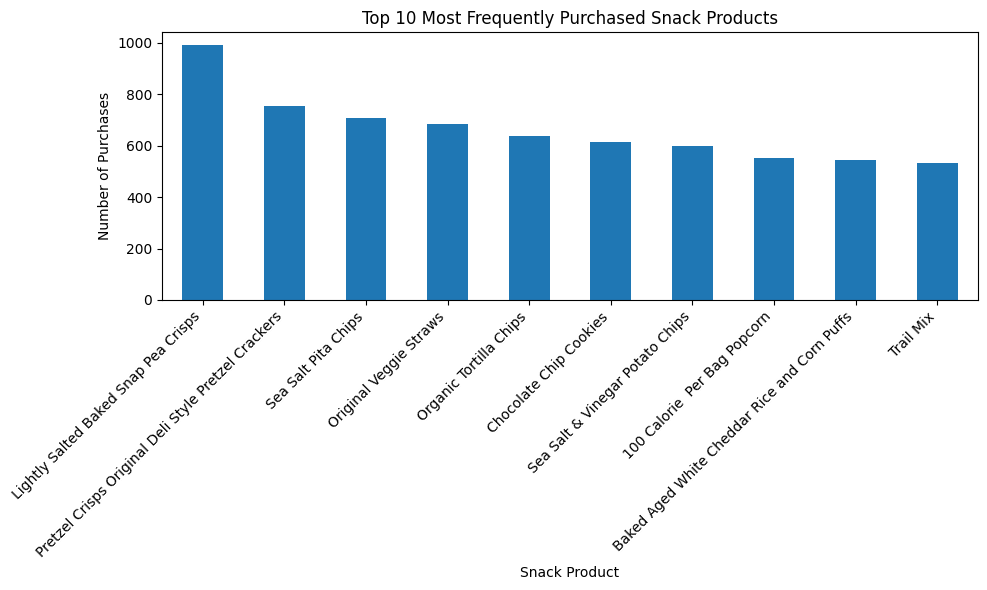

In [45]:
# Visualization for top 10 snack products

top_snack_products = order_products_train_df.merge(
    products_df[["product_id", "product_name", "department_id"]],
    on="product_id",
    how="left"
)

top_snack_products = top_snack_products[
    top_snack_products["department_id"] == 19
]["product_name"].value_counts().head(10)

top_snack_products.plot(kind="bar", figsize=(10, 6))

plt.title("Top 10 Most Frequently Purchased Snack Products")
plt.xlabel("Snack Product")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Statistical Analysis 2: Snack Purchase Behavior by Hour and Day

In [46]:
# Snack purchase behavior
snack_order_items = pd.merge(order_products_train_df, snack_products, on='product_id')
snack_orders_full = pd.merge(snack_order_items, orders_df, on='order_id')
snack_by_hour = snack_orders_full.groupby('order_hour_of_day')['order_id'].count()
snack_by_day = snack_orders_full.groupby('order_dow')['order_id'].count()

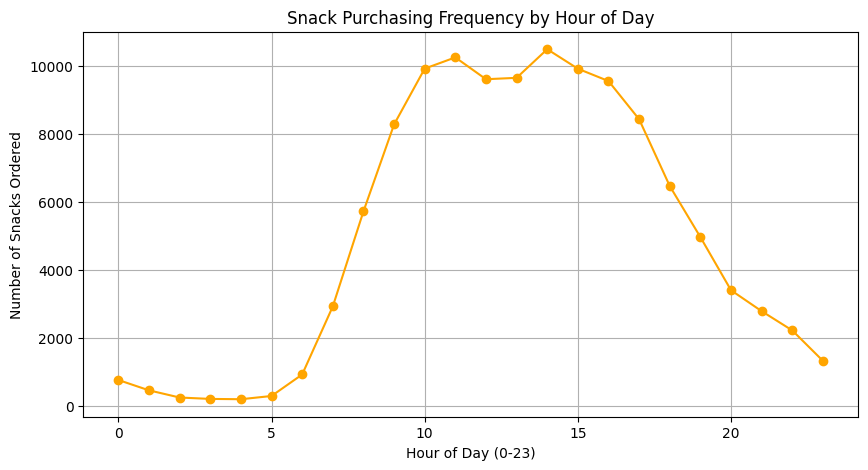

In [47]:
plt.figure(figsize=(10, 5))
snack_by_hour.plot(kind='line', marker='o', color='orange')
plt.title('Snack Purchasing Frequency by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Snacks Ordered')
plt.grid(True)
plt.show()

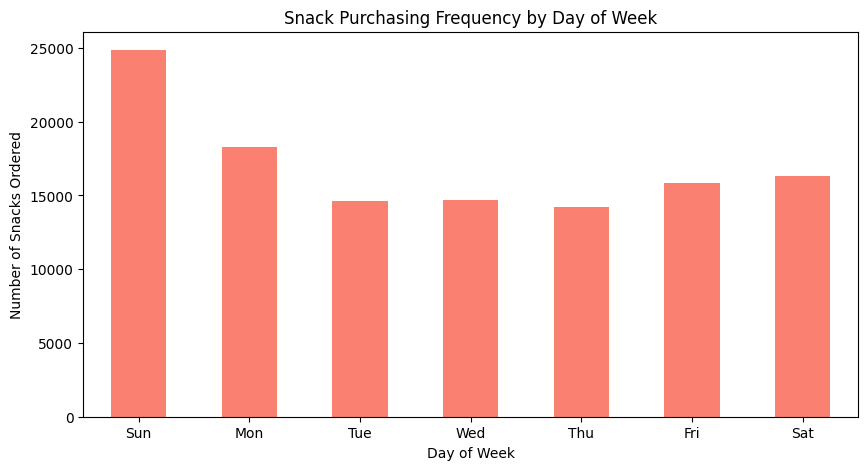

In [48]:
plt.figure(figsize=(10, 5))
days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
snack_by_day.plot(kind='bar', color='salmon')
plt.xticks(range(7), days, rotation=0)
plt.title('Snack Purchasing Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Snacks Ordered')
plt.show()

## Statistical Analysis 3: Snack Products by Aisle

In [49]:
# Snack products by aisle (counts)
snack_department = 19  # snacks department_id

snack_products = products_df[products_df["department_id"] == snack_department]

snack_products_with_aisles = snack_products.merge(aisles_df, on="aisle_id")

aisle_counts = snack_products_with_aisles["aisle"].value_counts().head(10)

print("Top 10 aisles with the most snack products:")
display(aisle_counts)

Top 10 aisles with the most snack products:


aisle
candy chocolate           1246
chips pretzels             989
cookies cakes              874
energy granola bars        832
crackers                   747
nuts seeds dried fruit     582
fruit vegetable snacks     356
popcorn jerky              316
mint gum                   168
ice cream toppings          85
Name: count, dtype: int64

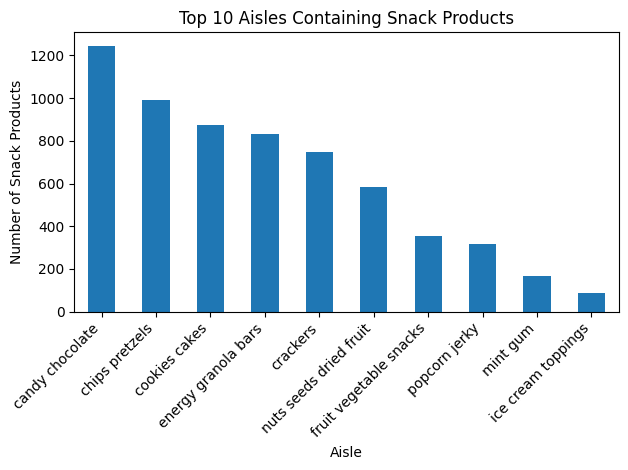

In [50]:
aisle_counts.plot(kind="bar")

plt.title("Top 10 Aisles Containing Snack Products")
plt.xlabel("Aisle")
plt.ylabel("Number of Snack Products")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Statistical Analysis 4: Orders Containing Snacks and Average Snack Items per Snack Order

In [51]:
# This analysis measures how often snacks appear in customer orders. Specifically, it shows how many train orders contain at least one snack item,
# what percentage of all train orders include snacks, and the average number of snack items in those snack containing orders.

snack_department = 19

# all product IDs that belong to the snacks department
snack_products = products_df[products_df["department_id"] == snack_department]
snack_product_ids = set(snack_products["product_id"])

# Find all rows in the training orders that contain snack products
snack_order_rows = order_products_train_df[
    order_products_train_df["product_id"].isin(snack_product_ids)
]

# Count total number of unique train orders
total_train_orders = order_products_train_df["order_id"].nunique()

# Count how many unique orders contain at least one snack item
snack_order_count = snack_order_rows["order_id"].nunique()

# Calculate percentage of train orders that contain snacks
snack_order_percentage = (snack_order_count / total_train_orders) * 100

# Count how many snack items appear in each snack-containing order
snack_items_per_order = snack_order_rows.groupby("order_id").size()

# Calculate average number of snack items in snack-containing orders
average_snack_items = snack_items_per_order.mean()

print("Total number of train orders:", total_train_orders)
print("Number of orders containing at least one snack item:", snack_order_count)
print("Percentage of train orders containing snacks: {:.2f}%".format(snack_order_percentage))
print("Average number of snack items per snack-containing order: {:.2f}".format(average_snack_items))

Total number of train orders: 131209
Number of orders containing at least one snack item: 57302
Percentage of train orders containing snacks: 43.67%
Average number of snack items per snack-containing order: 2.07


In [52]:
# Summary table for Statistical Analysis 4

summary_df = pd.DataFrame({
    "Metric": [
        "Total train orders",
        "Orders containing snacks",
        "Percentage of train orders containing snacks",
        "Average snack items per snack-containing order"
    ],
    "Value": [
        total_train_orders,
        snack_order_count,
        round(snack_order_percentage, 2),
        round(average_snack_items, 2)
    ]
})

display(summary_df)

,Metric,Value
0,Total train orders,131209.00
1,Orders containing snacks,57302.00
2,Percentage of train orders containing snacks,43.67
3,Average snack items per snack-containing order,2.07


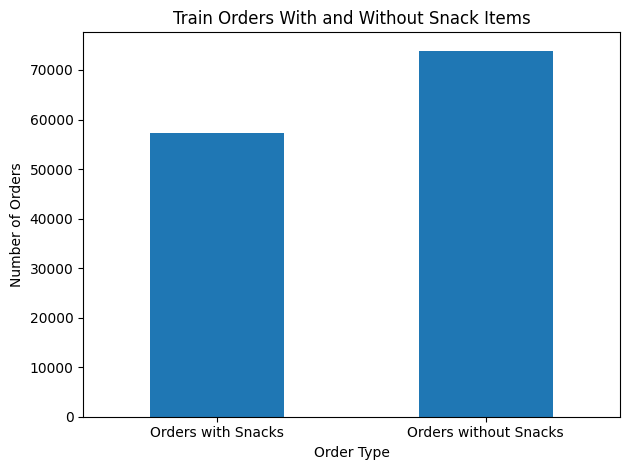

In [53]:
# Bar chart: orders with snacks vs orders without snacks

orders_without_snacks = total_train_orders - snack_order_count

order_comparison = pd.Series({
    "Orders with Snacks": snack_order_count,
    "Orders without Snacks": orders_without_snacks
})

order_comparison.plot(kind="bar")

plt.title("Train Orders With and Without Snack Items")
plt.xlabel("Order Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exploratory Basket Analysis 1: Snack Aisle Co-Occurrence

### Snacks Bought With Other Snacks

In [54]:
snack_orders_with_aisles = snack_orders_full.merge(aisles_df, on='aisle_id')
snack_basket = pd.crosstab(snack_orders_with_aisles['order_id'],
                           snack_orders_with_aisles['aisle'])
snack_basket_binary = (snack_basket > 0).astype(int)
correlation_matrix = snack_basket_binary.corr()
neg_patterns = correlation_matrix.unstack().sort_values()
neg_patterns = neg_patterns[neg_patterns < 0].drop_duplicates()
print("Top 5 Snack Categories that are RARELY bought together:")
print(neg_patterns.head(5))

Top 5 Snack Categories that are RARELY bought together:
aisle                   aisle                 
chips pretzels          nuts seeds dried fruit   -0.152431
energy granola bars     chips pretzels           -0.097600
crackers                chips pretzels           -0.095280
chips pretzels          candy chocolate          -0.089815
nuts seeds dried fruit  crackers                 -0.083106
dtype: float64


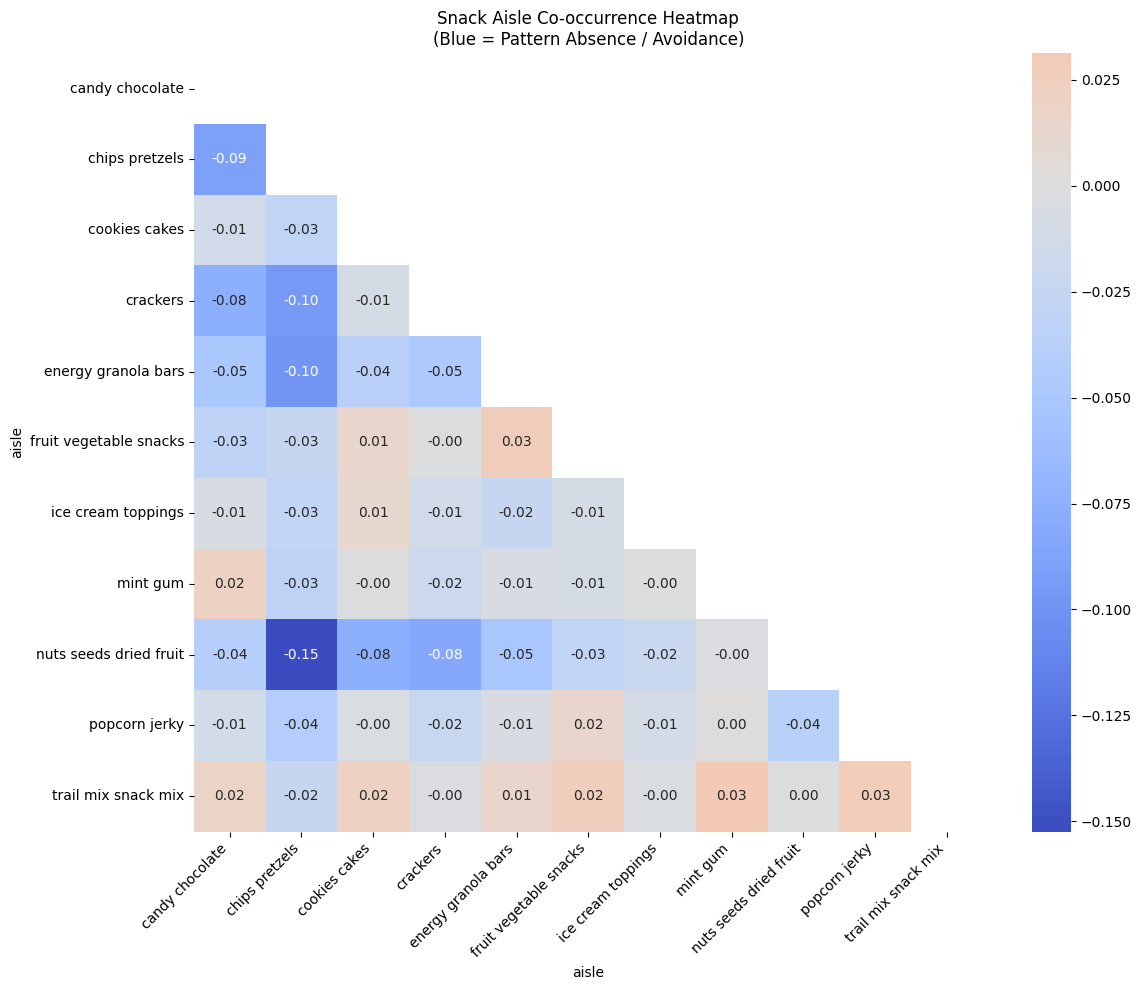

In [55]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Hides duplicate upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Snack Aisle Co-occurrence Heatmap\n(Blue = Pattern Absence / Avoidance)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Exploratory Basket Analysis 2: Snack Relationships with Other Departments by Order Size

### If a shopper goes to buy snacks, what else do they buy in their shopping trip?

In [56]:
full_data = order_products_train_df.merge(products_df, on='product_id')
full_data = full_data.merge(department_df, on='department_id')
order_sizes = full_data.groupby('order_id').size().reset_index(name='order_size')
full_data = full_data.merge(order_sizes, on='order_id')
def get_size_cat(size):
    if size <= 5: return 'Small (1-5)'
    elif size <= 15: return 'Medium (6-15)'
    else: return 'Large (16+)'

full_data['size_category'] = full_data['order_size'].apply(get_size_cat)
categories = ['Small (1-5)', 'Medium (6-15)', 'Large (16+)']
results = {}

for cat in categories:
    cat_data = full_data[full_data['size_category'] == cat]

    # Create Binary Basket per Category
    basket = pd.crosstab(cat_data['order_id'], cat_data['department'])
    basket_binary = (basket > 0).astype(int)

    # Calculate Correlation specifically for 'snacks'
    if 'snacks' in basket_binary.columns:
        snack_corr = basket_binary.corr()['snacks'].drop('snacks')
        results[cat] = snack_corr

results_df = pd.DataFrame(results)

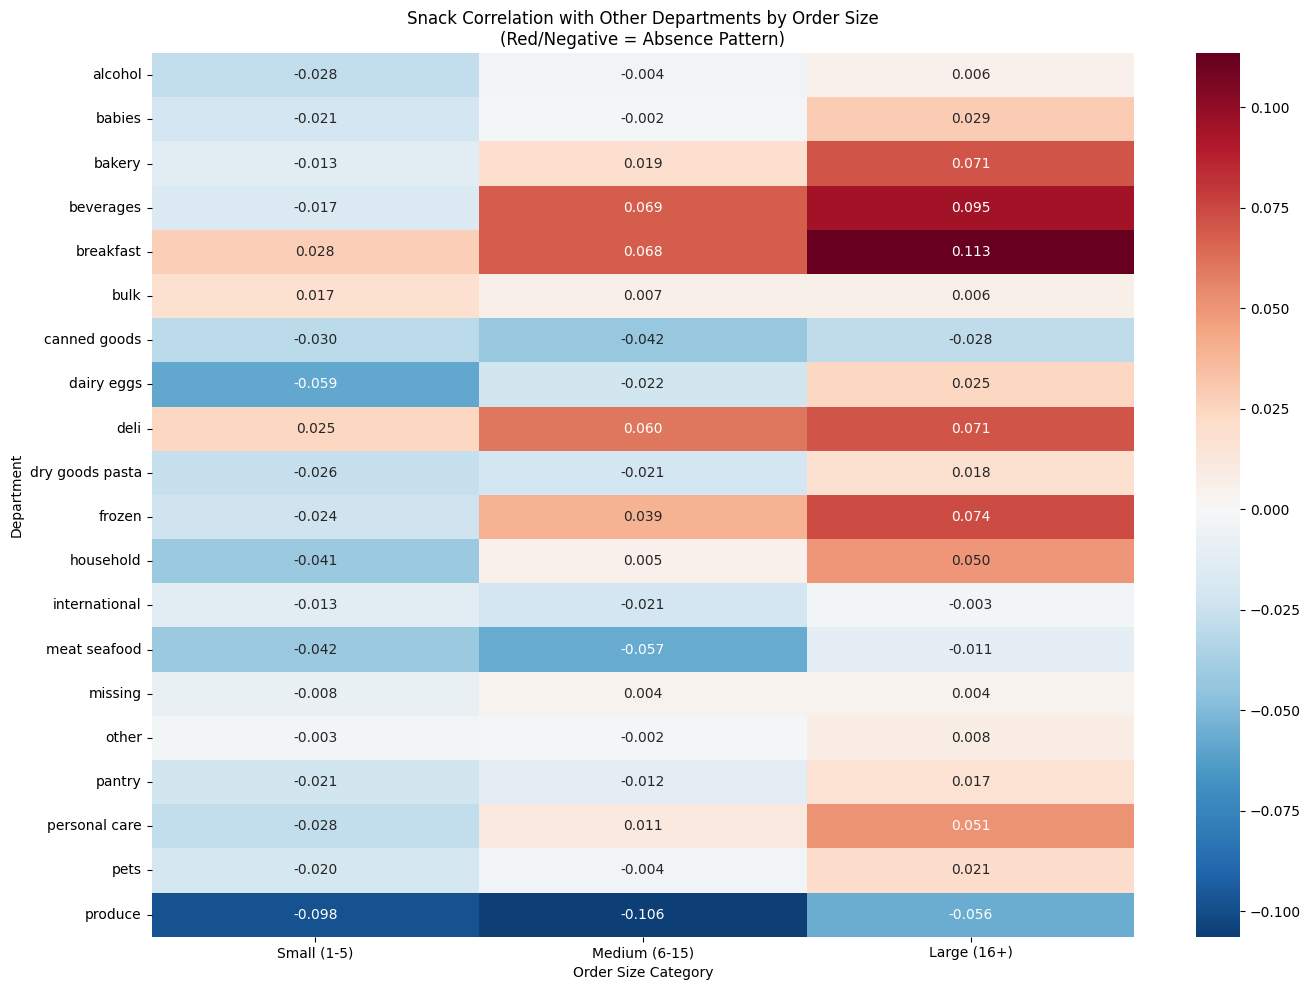

In [57]:
plt.figure(figsize=(14, 10))
sns.heatmap(results_df, annot=True, fmt=".3f", cmap='RdBu_r', center=0)
plt.title('Snack Correlation with Other Departments by Order Size\n(Red/Negative = Absence Pattern)')
plt.ylabel('Department')
plt.xlabel('Order Size Category')
plt.tight_layout()
plt.show()

# Pattern Mining 1: Cross Department Snack Rules

In [58]:
# This section mines cross department association rules involving the Snacks department.
# Each order is treated as a basket of departments, and FP-Growth is used to find rules showing which other departments tend to appear with snacks in the same shopping trip.

# cell to build the department basket

from mlxtend.frequent_patterns import fpgrowth, association_rules

# Merge order product data with product department information
cross_dept_data = order_products_train_df.merge(
    products_df[["product_id", "department_id"]],
    on="product_id",
    how="left"
)

cross_dept_data = cross_dept_data.merge(
    department_df[["department_id", "department"]],
    on="department_id",
    how="left"
)

# Create a basket where:
# rows = orders
# columns = departments
# values = whether that department appeared in the order
department_basket = pd.crosstab(
    cross_dept_data["order_id"],
    cross_dept_data["department"]
)

# Convert counts into 1s and 0s
department_basket = (department_basket > 0).astype(int)

print("Department basket shape:", department_basket.shape)
display(department_basket.head())

Department basket shape: (131209, 21)


department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,...,household,international,meat seafood,missing,other,pantry,personal care,pets,produce,snacks
order_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,1,0
36,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,0
38,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,1
96,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
98,0,0,1,1,0,0,1,1,1,0,...,1,0,1,0,0,1,1,0,1,1


In [59]:
# cell to mine the rules

# Remove departments we do not want to analyze
department_basket_small = department_basket.drop(columns=["missing", "other"], errors="ignore")

# Convert to True/False instead of 1/0
department_basket_small = department_basket_small.astype(bool)

# Run FP-Growth on only 2-item combinations
frequent_itemsets = fpgrowth(
    department_basket_small,
    min_support=0.01,
    use_colnames=True,
    max_len=2
)

# Generate association rules
cross_dept_rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

# Add support count
total_orders_for_rules = len(department_basket_small)
cross_dept_rules["support_count"] = (
    cross_dept_rules["support"] * total_orders_for_rules
).round().astype(int)

print("Number of frequent itemsets found:", len(frequent_itemsets))
print("Number of rules found:", len(cross_dept_rules))

Number of frequent itemsets found: 144
Number of rules found: 190


In [60]:
# cell to keep only simple snack related cross department rules

# Keep only simple one to one department rules involving snacks
snack_cross_rules = cross_dept_rules[
    (cross_dept_rules["antecedents"].apply(len) == 1) &
    (cross_dept_rules["consequents"].apply(len) == 1) &
    (
        cross_dept_rules["antecedents"].apply(lambda x: "snacks" in x) |
        cross_dept_rules["consequents"].apply(lambda x: "snacks" in x)
    )
].copy()

# Convert frozensets to readable text
snack_cross_rules["antecedent_text"] = snack_cross_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

snack_cross_rules["consequent_text"] = snack_cross_rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

# Sort by lift first, then confidence, then support count
snack_cross_rules = snack_cross_rules.sort_values(
    by=["lift", "confidence", "support_count"],
    ascending=[False, False, False]
)

# Show the most important columns
cross_rule_results = snack_cross_rules[
    [
        "antecedent_text",
        "consequent_text",
        "support_count",
        "support",
        "confidence",
        "lift"
    ]
]

display(cross_rule_results.head(15))

,antecedent_text,consequent_text,support_count,support,confidence,lift
153,breakfast,snacks,13452,0.102523,0.614836,1.407840
154,snacks,breakfast,13452,0.102523,0.234756,1.407840
31,snacks,deli,18865,0.143778,0.329221,1.338147
30,deli,snacks,18865,0.143778,0.584399,1.338147
143,babies,snacks,3635,0.027704,0.571361,1.308292
65,bakery,snacks,20140,0.153496,0.552932,1.266093
64,snacks,bakery,20140,0.153496,0.351471,1.266093
122,dry goods pasta,snacks,14253,0.108628,0.550819,1.261255
121,snacks,dry goods pasta,14253,0.108628,0.248735,1.261255
175,international,snacks,5247,0.039990,0.540037,1.236566


In [61]:
# Cleaner final table for Pattern Mining 1

cross_rule_results_clean = cross_rule_results.copy()

cross_rule_results_clean["support"] = cross_rule_results_clean["support"].round(3)
cross_rule_results_clean["confidence"] = cross_rule_results_clean["confidence"].round(3)
cross_rule_results_clean["lift"] = cross_rule_results_clean["lift"].round(3)

cross_rule_results_clean = cross_rule_results_clean.reset_index(drop=True)

display(cross_rule_results_clean.head(10))

,antecedent_text,consequent_text,support_count,support,confidence,lift
0,breakfast,snacks,13452,0.103,0.615,1.408
1,snacks,breakfast,13452,0.103,0.235,1.408
2,snacks,deli,18865,0.144,0.329,1.338
3,deli,snacks,18865,0.144,0.584,1.338
4,babies,snacks,3635,0.028,0.571,1.308
5,bakery,snacks,20140,0.153,0.553,1.266
6,snacks,bakery,20140,0.153,0.351,1.266
7,dry goods pasta,snacks,14253,0.109,0.551,1.261
8,snacks,dry goods pasta,14253,0.109,0.249,1.261
9,international,snacks,5247,0.040,0.540,1.237


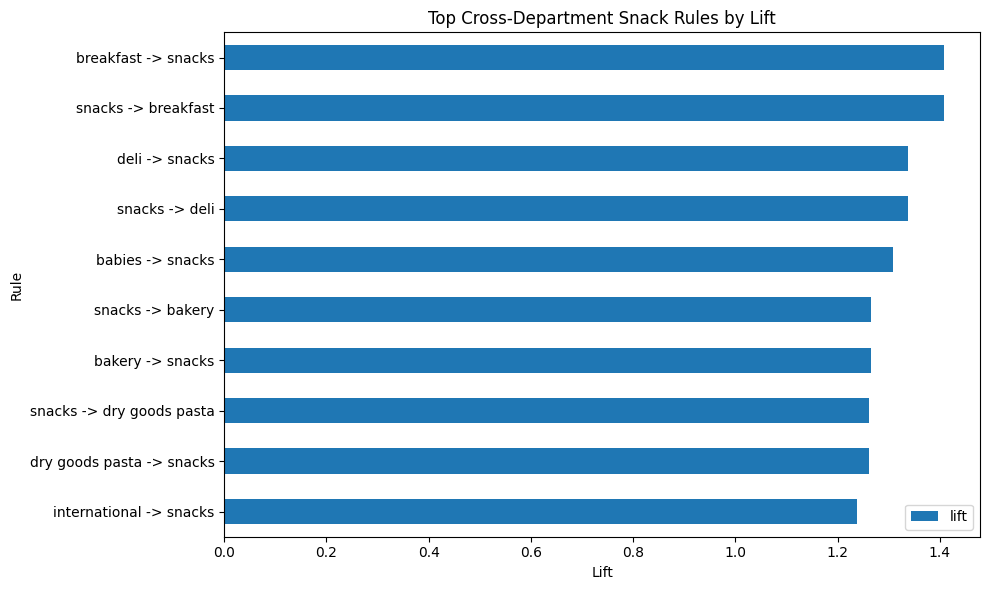

In [62]:
# chart cell

# chart top snack related cross department rules by lift

top_cross_rules = cross_rule_results_clean.head(10).copy()
top_cross_rules["rule"] = (
    top_cross_rules["antecedent_text"] + " -> " + top_cross_rules["consequent_text"]
)

top_cross_rules = top_cross_rules.sort_values("lift")

top_cross_rules.plot(
    kind="barh",
    x="rule",
    y="lift",
    figsize=(10, 6)
)

plt.title("Top Cross-Department Snack Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.tight_layout()
plt.show()

# Pattern Mining 2: Multilevel Snack Rules

In [63]:
# This section uses multilevel pattern mining on the Snacks department hierarchy. Orders are represented using three levels of snack information: department, aisle, and product.
# FP-Growth is then used to find association rules across these levels, such as department-to-aisle or aisle-to-product relationships.

# this cell builds a multi level basket using snack department, snack aisles, and top snack products

# Merge product information
multilevel_data = order_products_train_df.merge(
    products_df[["product_id", "product_name", "department_id", "aisle_id"]],
    on="product_id",
    how="left"
)

multilevel_data = multilevel_data.merge(
    department_df[["department_id", "department"]],
    on="department_id",
    how="left"
)

multilevel_data = multilevel_data.merge(
    aisles_df[["aisle_id", "aisle"]],
    on="aisle_id",
    how="left"
)

# Keep only snack rows for choosing top aisles/products
snack_data = multilevel_data[multilevel_data["department"] == "snacks"].copy()

# Choose the most common snack aisles
top_snack_aisles = snack_data["aisle"].value_counts().head(10).index.tolist()

# Choose the most common snack products
top_snack_products = snack_data["product_name"].value_counts().head(20).index.tolist()

print("Top snack aisles used:")
print(top_snack_aisles)
print()

print("Top snack products used:")
print(top_snack_products)

Top snack aisles used:
['chips pretzels', 'crackers', 'energy granola bars', 'nuts seeds dried fruit', 'candy chocolate', 'cookies cakes', 'popcorn jerky', 'fruit vegetable snacks', 'trail mix snack mix', 'mint gum']

Top snack products used:
['Lightly Salted Baked Snap Pea Crisps', 'Pretzel Crisps Original Deli Style Pretzel Crackers', 'Sea Salt Pita Chips', 'Original Veggie Straws', 'Organic Tortilla Chips', 'Chocolate Chip Cookies', 'Sea Salt & Vinegar Potato Chips', '100 Calorie  Per Bag Popcorn', 'Baked Aged White Cheddar Rice and Corn Puffs', 'Trail Mix', 'Pita Chips Simply Naked', 'Organic Thompson Seedless Raisins', 'Sea Salt Potato Chips', 'Boomchickapop Sea Salt Popcorn', 'Hint Of Sea Salt Almond Nut Thins', 'Mixed Fruit Fruit Snacks', 'Organic Whole Cashews', 'Organic Bunny Fruit Snacks Berry Patch', 'Organic Summer Strawberry Bunny Fruit Snacks', 'Organic Blue Corn Tortilla Chips']


In [64]:
# Create multilevel basket per order
# cell to create the order baskets

# Keep only snack rows and only the columns we need
snack_only_data = multilevel_data[multilevel_data["department"] == "snacks"][
    ["order_id", "aisle", "product_name"]
].copy()

multilevel_baskets = []

for order_id, group in snack_only_data.groupby("order_id"):
    basket_items = set()

    # Every order in this filtered data already contains snacks
    basket_items.add("DEPT_snacks")

    # Add snack aisle level items
    snack_aisles_in_order = group["aisle"].dropna().unique()
    for aisle_name in snack_aisles_in_order:
        if aisle_name in top_snack_aisles:
            basket_items.add("AISLE_" + aisle_name)

    # Add snack product level items
    snack_products_in_order = group["product_name"].dropna().unique()
    for product_name in snack_products_in_order:
        if product_name in top_snack_products:
            basket_items.add("PRODUCT_" + product_name)

    # Turn set into dictionary for DataFrame creation
    basket_dict = {}
    for item in basket_items:
        basket_dict[item] = True

    multilevel_baskets.append(basket_dict)

multilevel_basket_df = pd.DataFrame(multilevel_baskets).fillna(False).astype(bool)

print("Multilevel basket shape:", multilevel_basket_df.shape)
display(multilevel_basket_df.head())

Multilevel basket shape: (57302, 31)


,AISLE_nuts seeds dried fruit,DEPT_snacks,AISLE_crackers,AISLE_chips pretzels,AISLE_popcorn jerky,AISLE_candy chocolate,AISLE_energy granola bars,AISLE_cookies cakes,PRODUCT_Organic Whole Cashews,AISLE_trail mix snack mix,...,PRODUCT_Original Veggie Straws,PRODUCT_Trail Mix,PRODUCT_Sea Salt & Vinegar Potato Chips,PRODUCT_Lightly Salted Baked Snap Pea Crisps,PRODUCT_100 Calorie Per Bag Popcorn,PRODUCT_Boomchickapop Sea Salt Popcorn,PRODUCT_Pita Chips Simply Naked,PRODUCT_Mixed Fruit Fruit Snacks,PRODUCT_Baked Aged White Cheddar Rice and Corn Puffs,PRODUCT_Organic Summer Strawberry Bunny Fruit Snacks
0,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [65]:
# Mine multilevel frequent itemsets and rules
# this is the mining cell

multilevel_itemsets = fpgrowth(
    multilevel_basket_df,
    min_support=0.003,
    use_colnames=True,
    max_len=2
)

multilevel_rules = association_rules(
    multilevel_itemsets,
    metric="confidence",
    min_threshold=0.20
)

# Add support count
total_multilevel_orders = len(multilevel_basket_df)
multilevel_rules["support_count"] = (
    multilevel_rules["support"] * total_multilevel_orders
).round().astype(int)

print("Number of multilevel itemsets found:", len(multilevel_itemsets))
print("Number of multilevel rules found:", len(multilevel_rules))

Number of multilevel itemsets found: 129
Number of multilevel rules found: 81


c:\Users\spenc\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlxtend\frequent_patterns\association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [66]:
# Keep only meaningful multilevel snack rules
# filtering/results cell

def get_level(item_name):
    if item_name.startswith("DEPT_"):
        return "department"
    elif item_name.startswith("AISLE_"):
        return "aisle"
    elif item_name.startswith("PRODUCT_"):
        return "product"
    else:
        return "other"

# Keep one-to-one rules only
multilevel_rules_simple = multilevel_rules[
    (multilevel_rules["antecedents"].apply(len) == 1) &
    (multilevel_rules["consequents"].apply(len) == 1)
].copy()

# Convert frozensets to text
multilevel_rules_simple["antecedent_text"] = multilevel_rules_simple["antecedents"].apply(
    lambda x: list(x)[0]
)
multilevel_rules_simple["consequent_text"] = multilevel_rules_simple["consequents"].apply(
    lambda x: list(x)[0]
)

# Get level of each side
multilevel_rules_simple["antecedent_level"] = multilevel_rules_simple["antecedent_text"].apply(get_level)
multilevel_rules_simple["consequent_level"] = multilevel_rules_simple["consequent_text"].apply(get_level)

# Keep only rules that connect different levels
multilevel_rules_simple = multilevel_rules_simple[
    multilevel_rules_simple["antecedent_level"] != multilevel_rules_simple["consequent_level"]
].copy()

# Remove rules with confidence = 1.0 because they are usually too obvious
multilevel_rules_simple = multilevel_rules_simple[
    multilevel_rules_simple["confidence"] < 0.999
].copy()

# Remove weak or too-obvious rules
multilevel_rules_simple = multilevel_rules_simple[
    multilevel_rules_simple["lift"] > 1.05
].copy()

# Remove very tiny patterns
multilevel_rules_simple = multilevel_rules_simple[
    multilevel_rules_simple["support_count"] >= 200
].copy()

# Clean text by removing prefixes
multilevel_rules_simple["antecedent_text"] = multilevel_rules_simple["antecedent_text"].str.replace("DEPT_", "", regex=False)
multilevel_rules_simple["antecedent_text"] = multilevel_rules_simple["antecedent_text"].str.replace("AISLE_", "", regex=False)
multilevel_rules_simple["antecedent_text"] = multilevel_rules_simple["antecedent_text"].str.replace("PRODUCT_", "", regex=False)

multilevel_rules_simple["consequent_text"] = multilevel_rules_simple["consequent_text"].str.replace("DEPT_", "", regex=False)
multilevel_rules_simple["consequent_text"] = multilevel_rules_simple["consequent_text"].str.replace("AISLE_", "", regex=False)
multilevel_rules_simple["consequent_text"] = multilevel_rules_simple["consequent_text"].str.replace("PRODUCT_", "", regex=False)

# Round results
multilevel_rules_simple["support"] = multilevel_rules_simple["support"].round(3)
multilevel_rules_simple["confidence"] = multilevel_rules_simple["confidence"].round(3)
multilevel_rules_simple["lift"] = multilevel_rules_simple["lift"].round(3)

# Sort results
multilevel_rules_simple = multilevel_rules_simple.sort_values(
    by=["lift", "confidence", "support_count"],
    ascending=[False, False, False]
)

multilevel_results = multilevel_rules_simple[
    [
        "antecedent_text",
        "consequent_text",
        "antecedent_level",
        "consequent_level",
        "support_count",
        "support",
        "confidence",
        "lift"
    ]
].reset_index(drop=True)

display(multilevel_results.head(15))

,antecedent_text,consequent_text,antecedent_level,consequent_level,support_count,support,confidence,lift
0,trail mix snack mix,Trail Mix,aisle,product,533,0.009,0.379,40.726
1,Lightly Salted Baked Snap Pea Crisps,energy granola bars,product,aisle,216,0.004,0.218,1.130
2,Organic Bunny Fruit Snacks Berry Patch,chips pretzels,product,aisle,210,0.004,0.442,1.093
3,Original Veggie Straws,chips pretzels,product,aisle,292,0.005,0.427,1.055


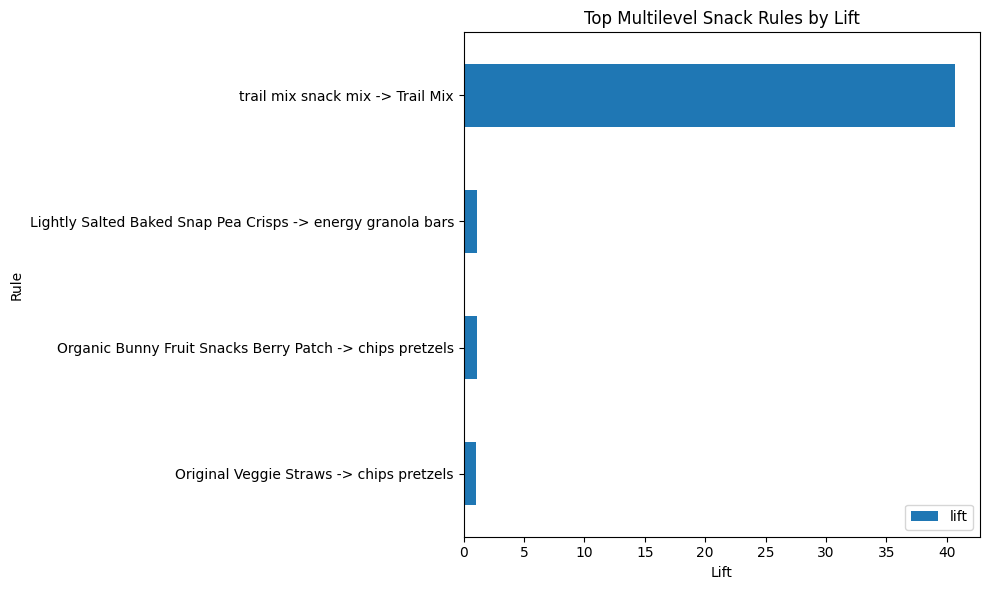

In [67]:
# chart cell
# top multilevel rules by lift

top_multilevel_rules = multilevel_results.head(10).copy()
top_multilevel_rules["rule"] = (
    top_multilevel_rules["antecedent_text"] + " -> " + top_multilevel_rules["consequent_text"]
)

top_multilevel_rules = top_multilevel_rules.sort_values("lift")

top_multilevel_rules.plot(
    kind="barh",
    x="rule",
    y="lift",
    figsize=(10, 6)
)

plt.title("Top Multilevel Snack Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.tight_layout()
plt.show()

# Pattern Mining 3: Multidimensional Snack Rules

In [68]:
# setup cell
# Build context and shopping dimensions for snack containing orders
# This section uses multidimensional pattern mining to study snack-related purchasing behavior. 
# Instead of only analyzing product hierarchy, this analysis combines shopping context (time of day, weekday/weekend, and order size) with snack-related content (snack aisles and other departments purchased with snacks). 
# FP-Growth is then used to find rules across these multiple dimensions.


# Merge product and order information
multi_data = order_products_train_df.merge(
    products_df[["product_id", "department_id", "aisle_id"]],
    on="product_id",
    how="left"
)

multi_data = multi_data.merge(
    department_df[["department_id", "department"]],
    on="department_id",
    how="left"
)

multi_data = multi_data.merge(
    aisles_df[["aisle_id", "aisle"]],
    on="aisle_id",
    how="left"
)

multi_data = multi_data.merge(
    orders_df[["order_id", "order_dow", "order_hour_of_day"]],
    on="order_id",
    how="left"
)

# Find snack-containing orders
snack_order_ids = multi_data.loc[
    multi_data["department"] == "snacks", "order_id"
].unique()

# Keep only snack-containing orders
multi_data = multi_data[multi_data["order_id"].isin(snack_order_ids)].copy()

# Total items per order
order_sizes = multi_data.groupby("order_id").size()

def get_time_bucket(hour):
    if 5 <= hour < 11:
        return "TIME_morning"
    elif 11 <= hour < 17:
        return "TIME_afternoon"
    elif 17 <= hour < 22:
        return "TIME_evening"
    else:
        return "TIME_night"

def get_day_type(dow):
    if dow in [0, 6]:
        return "DAY_weekend"
    else:
        return "DAY_weekday"

def get_size_bucket(size):
    if size <= 5:
        return "SIZE_small"
    elif size <= 15:
        return "SIZE_medium"
    else:
        return "SIZE_large"

# Add order size bucket
multi_data["order_size"] = multi_data["order_id"].map(order_sizes)
multi_data["size_bucket"] = multi_data["order_size"].apply(get_size_bucket)
multi_data["time_bucket"] = multi_data["order_hour_of_day"].apply(get_time_bucket)
multi_data["day_type"] = multi_data["order_dow"].apply(get_day_type)

# Top snack aisles
top_snack_aisles_multi = multi_data.loc[
    multi_data["department"] == "snacks", "aisle"
].value_counts().head(8).index.tolist()

# Top non-snack departments inside snack orders
top_other_departments_multi = multi_data.loc[
    (multi_data["department"] != "snacks") &
    (multi_data["department"] != "missing") &
    (multi_data["department"] != "other"),
    "department"
].value_counts().head(8).index.tolist()

print("Top snack aisles used:")
print(top_snack_aisles_multi)
print()

print("Top non-snack departments used:")
print(top_other_departments_multi)

Top snack aisles used:
['chips pretzels', 'crackers', 'energy granola bars', 'nuts seeds dried fruit', 'candy chocolate', 'cookies cakes', 'popcorn jerky', 'fruit vegetable snacks']

Top non-snack departments used:
['produce', 'dairy eggs', 'beverages', 'frozen', 'pantry', 'bakery', 'deli', 'canned goods']


In [69]:
# basket building cell
# Create multidimensional basket per snack-containing order

multi_baskets = []

for order_id, group in multi_data.groupby("order_id"):
    basket_items = set()

    # Add context dimensions (one of each per order)
    first_row = group.iloc[0]
    basket_items.add(first_row["time_bucket"])
    basket_items.add(first_row["day_type"])
    basket_items.add(first_row["size_bucket"])

    # Add top snack aisles in the order
    snack_aisles_in_order = group.loc[
        (group["department"] == "snacks") &
        (group["aisle"].isin(top_snack_aisles_multi)),
        "aisle"
    ].dropna().unique()

    for aisle_name in snack_aisles_in_order:
        basket_items.add("SNACK_AISLE_" + aisle_name)

    # Add top non-snack departments in the order
    other_departments_in_order = group.loc[
        (group["department"].isin(top_other_departments_multi)),
        "department"
    ].dropna().unique()

    for dept_name in other_departments_in_order:
        basket_items.add("DEPT_" + dept_name)

    basket_dict = {}
    for item in basket_items:
        basket_dict[item] = True

    multi_baskets.append(basket_dict)

multidim_basket_df = pd.DataFrame(multi_baskets).fillna(False).astype(bool)

print("Multidimensional basket shape:", multidim_basket_df.shape)
display(multidim_basket_df.head())

Multidimensional basket shape: (57302, 25)


,TIME_afternoon,DEPT_frozen,DEPT_pantry,DEPT_produce,DAY_weekend,SNACK_AISLE_nuts seeds dried fruit,SIZE_medium,SNACK_AISLE_crackers,DEPT_deli,DEPT_beverages,...,DAY_weekday,SNACK_AISLE_chips pretzels,SNACK_AISLE_popcorn jerky,TIME_evening,SNACK_AISLE_candy chocolate,SNACK_AISLE_energy granola bars,SNACK_AISLE_cookies cakes,SIZE_small,SNACK_AISLE_fruit vegetable snacks,TIME_night
0,True,True,True,True,True,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,True,False,False,False,True,True,True,...,True,False,False,False,False,False,False,False,False,False
2,True,False,False,True,False,False,True,False,False,True,...,True,True,False,False,False,False,False,False,False,False
3,True,False,True,True,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
4,False,False,False,True,True,False,True,False,False,False,...,False,False,False,True,True,False,False,False,False,False


In [70]:
# mining cell
# Mine multidimensional frequent itemsets and rules

multidim_itemsets = fpgrowth(
    multidim_basket_df,
    min_support=0.008,
    use_colnames=True,
    max_len=2
)

multidim_rules = association_rules(
    multidim_itemsets,
    metric="confidence",
    min_threshold=0.20
)

# Add support count
total_multidim_orders = len(multidim_basket_df)
multidim_rules["support_count"] = (
    multidim_rules["support"] * total_multidim_orders
).round().astype(int)

print("Number of multidimensional itemsets found:", len(multidim_itemsets))
print("Number of multidimensional rules found:", len(multidim_rules))

Number of multidimensional itemsets found: 309
Number of multidimensional rules found: 396


In [71]:
# filtering/results cell
# Keep only meaningful multidimensional rules

def get_multi_type(item_name):
    if item_name.startswith("TIME_"):
        return "time"
    elif item_name.startswith("DAY_"):
        return "day"
    elif item_name.startswith("SIZE_"):
        return "size"
    elif item_name.startswith("SNACK_AISLE_"):
        return "snack_aisle"
    elif item_name.startswith("DEPT_"):
        return "department"
    else:
        return "other"

# Keep one-to-one rules only
multidim_rules_simple = multidim_rules[
    (multidim_rules["antecedents"].apply(len) == 1) &
    (multidim_rules["consequents"].apply(len) == 1)
].copy()

# Convert frozensets to text
multidim_rules_simple["antecedent_text"] = multidim_rules_simple["antecedents"].apply(
    lambda x: list(x)[0]
)
multidim_rules_simple["consequent_text"] = multidim_rules_simple["consequents"].apply(
    lambda x: list(x)[0]
)

# Get type of each side
multidim_rules_simple["antecedent_type"] = multidim_rules_simple["antecedent_text"].apply(get_multi_type)
multidim_rules_simple["consequent_type"] = multidim_rules_simple["consequent_text"].apply(get_multi_type)

# Keep only rules where one side is context and the other side is shopping content
context_types = ["time", "day", "size"]
content_types = ["snack_aisle", "department"]

multidim_rules_simple = multidim_rules_simple[
    multidim_rules_simple["antecedent_type"].isin(context_types) &
    multidim_rules_simple["consequent_type"].isin(content_types)
].copy()

# Remove weak rules
multidim_rules_simple = multidim_rules_simple[
    multidim_rules_simple["lift"] > 1.03
].copy()

multidim_rules_simple = multidim_rules_simple[
    multidim_rules_simple["support_count"] >= 300
].copy()

# Clean text labels
multidim_rules_simple["antecedent_text"] = multidim_rules_simple["antecedent_text"].str.replace("TIME_", "", regex=False)
multidim_rules_simple["antecedent_text"] = multidim_rules_simple["antecedent_text"].str.replace("DAY_", "", regex=False)
multidim_rules_simple["antecedent_text"] = multidim_rules_simple["antecedent_text"].str.replace("SIZE_", "", regex=False)
multidim_rules_simple["antecedent_text"] = multidim_rules_simple["antecedent_text"].str.replace("SNACK_AISLE_", "", regex=False)
multidim_rules_simple["antecedent_text"] = multidim_rules_simple["antecedent_text"].str.replace("DEPT_", "", regex=False)

multidim_rules_simple["consequent_text"] = multidim_rules_simple["consequent_text"].str.replace("TIME_", "", regex=False)
multidim_rules_simple["consequent_text"] = multidim_rules_simple["consequent_text"].str.replace("DAY_", "", regex=False)
multidim_rules_simple["consequent_text"] = multidim_rules_simple["consequent_text"].str.replace("SIZE_", "", regex=False)
multidim_rules_simple["consequent_text"] = multidim_rules_simple["consequent_text"].str.replace("SNACK_AISLE_", "", regex=False)
multidim_rules_simple["consequent_text"] = multidim_rules_simple["consequent_text"].str.replace("DEPT_", "", regex=False)

# Round and sort
multidim_rules_simple["support"] = multidim_rules_simple["support"].round(3)
multidim_rules_simple["confidence"] = multidim_rules_simple["confidence"].round(3)
multidim_rules_simple["lift"] = multidim_rules_simple["lift"].round(3)

multidim_rules_simple = multidim_rules_simple.sort_values(
    by=["lift", "confidence", "support_count"],
    ascending=[False, False, False]
)

multidim_results = multidim_rules_simple[
    [
        "antecedent_text",
        "consequent_text",
        "antecedent_type",
        "consequent_type",
        "support_count",
        "support",
        "confidence",
        "lift"
    ]
].reset_index(drop=True)

display(multidim_results.head(15))

,antecedent_text,consequent_text,antecedent_type,consequent_type,support_count,support,confidence,lift
0,large,canned goods,size,department,9307,0.162,0.461,1.717
1,large,bakery,size,department,11086,0.193,0.549,1.561
2,large,deli,size,department,10263,0.179,0.508,1.543
3,large,pantry,size,department,12899,0.225,0.638,1.485
4,large,frozen,size,department,14010,0.244,0.693,1.447
5,large,crackers,size,snack_aisle,7245,0.126,0.359,1.311
6,large,energy granola bars,size,snack_aisle,5025,0.088,0.249,1.289
7,large,dairy eggs,size,department,19112,0.334,0.946,1.274
8,large,beverages,size,department,13853,0.242,0.686,1.259
9,large,nuts seeds dried fruit,size,snack_aisle,4610,0.080,0.228,1.242


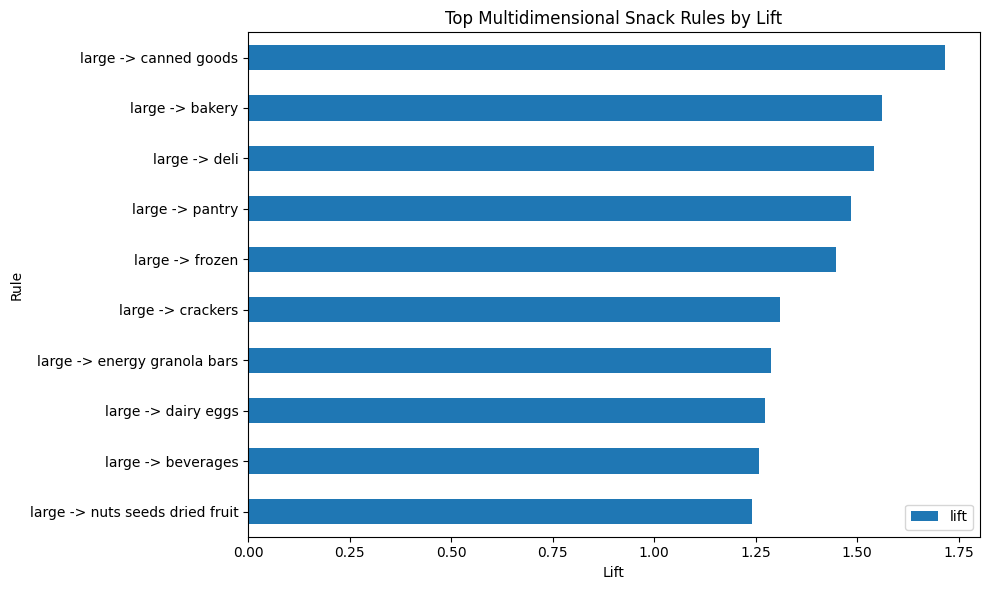

In [72]:
# chart cell 
# chart top multidimensional rules by lift

top_multidim_rules = multidim_results.head(10).copy()
top_multidim_rules["rule"] = (
    top_multidim_rules["antecedent_text"] + " -> " + top_multidim_rules["consequent_text"]
)

top_multidim_rules = top_multidim_rules.sort_values("lift")

top_multidim_rules.plot(
    kind="barh",
    x="rule",
    y="lift",
    figsize=(10, 6)
)

plt.title("Top Multidimensional Snack Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.tight_layout()
plt.show()

# Pattern Mining 4: Rare Snack Aisle Rules with Other Departments

In [73]:
# setup cell

# This section focuses on rare but potentially meaningful snack-related rules. Instead of looking for the most common patterns, this analysis uses a lower minimum support threshold to find less frequent snack aisle relationships with other departments. 
# The goal is to identify smaller but still meaningful shopping patterns that may be missed in broader association mining.

# Merge product, department, and aisle information
rare_data = order_products_train_df.merge(
    products_df[["product_id", "department_id", "aisle_id"]],
    on="product_id",
    how="left"
)

rare_data = rare_data.merge(
    department_df[["department_id", "department"]],
    on="department_id",
    how="left"
)

rare_data = rare_data.merge(
    aisles_df[["aisle_id", "aisle"]],
    on="aisle_id",
    how="left"
)

# Find orders that contain at least one snack item
rare_snack_order_ids = rare_data.loc[
    rare_data["department"] == "snacks", "order_id"
].unique()

# Keep only snack-containing orders
rare_data = rare_data[rare_data["order_id"].isin(rare_snack_order_ids)].copy()

# Top snack aisles
top_snack_aisles_rare = rare_data.loc[
    rare_data["department"] == "snacks", "aisle"
].value_counts().head(10).index.tolist()

# Top non-snack departments
top_other_departments_rare = rare_data.loc[
    (rare_data["department"] != "snacks") &
    (rare_data["department"] != "missing") &
    (rare_data["department"] != "other"),
    "department"
].value_counts().head(10).index.tolist()

print("Top snack aisles used:")
print(top_snack_aisles_rare)
print()

print("Top non-snack departments used:")
print(top_other_departments_rare)

Top snack aisles used:
['chips pretzels', 'crackers', 'energy granola bars', 'nuts seeds dried fruit', 'candy chocolate', 'cookies cakes', 'popcorn jerky', 'fruit vegetable snacks', 'trail mix snack mix', 'mint gum']

Top non-snack departments used:
['produce', 'dairy eggs', 'beverages', 'frozen', 'pantry', 'bakery', 'deli', 'canned goods', 'dry goods pasta', 'breakfast']


In [74]:
# basket building cell
# Create rare pattern basket per snack containing order

rare_baskets = []

for order_id, group in rare_data.groupby("order_id"):
    basket_items = set()

    # Add snack aisles in the order
    snack_aisles_in_order = group.loc[
        (group["department"] == "snacks") &
        (group["aisle"].isin(top_snack_aisles_rare)),
        "aisle"
    ].dropna().unique()

    for aisle_name in snack_aisles_in_order:
        basket_items.add("SNACK_AISLE_" + aisle_name)

    # Add non-snack departments in the order
    other_departments_in_order = group.loc[
        group["department"].isin(top_other_departments_rare),
        "department"
    ].dropna().unique()

    for dept_name in other_departments_in_order:
        basket_items.add("OTHER_DEPT_" + dept_name)

    # Keep only orders that actually contain both types of items
    if len(basket_items) > 1:
        basket_dict = {}
        for item in basket_items:
            basket_dict[item] = True
        rare_baskets.append(basket_dict)

rare_basket_df = pd.DataFrame(rare_baskets).fillna(False).astype(bool)

print("Rare basket shape:", rare_basket_df.shape)
display(rare_basket_df.head())

Rare basket shape: (56267, 20)


,OTHER_DEPT_produce,OTHER_DEPT_pantry,SNACK_AISLE_nuts seeds dried fruit,OTHER_DEPT_frozen,OTHER_DEPT_deli,SNACK_AISLE_crackers,OTHER_DEPT_dairy eggs,OTHER_DEPT_canned goods,OTHER_DEPT_beverages,OTHER_DEPT_bakery,OTHER_DEPT_dry goods pasta,SNACK_AISLE_chips pretzels,SNACK_AISLE_popcorn jerky,OTHER_DEPT_breakfast,SNACK_AISLE_candy chocolate,SNACK_AISLE_energy granola bars,SNACK_AISLE_cookies cakes,SNACK_AISLE_trail mix snack mix,SNACK_AISLE_fruit vegetable snacks,SNACK_AISLE_mint gum
0,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,True,False,True,True,True,True,True,True,True,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False
3,True,True,False,False,False,True,True,False,False,True,True,False,True,False,False,False,False,False,False,False
4,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False


In [75]:
# mining cell
# Mine rare snack related itemsets and rules

rare_itemsets = fpgrowth(
    rare_basket_df,
    min_support=0.002,
    use_colnames=True,
    max_len=2
)

rare_rules = association_rules(
    rare_itemsets,
    metric="confidence",
    min_threshold=0.15
)

# Add support count
total_rare_orders = len(rare_basket_df)
rare_rules["support_count"] = (
    rare_rules["support"] * total_rare_orders
).round().astype(int)

print("Number of rare itemsets found:", len(rare_itemsets))
print("Number of rare rules found:", len(rare_rules))

Number of rare itemsets found: 205
Number of rare rules found: 270


In [76]:
# filtering/results cell
# Keep only meaningful rare snack aisle -> other department rules

rare_rules_simple = rare_rules[
    (rare_rules["antecedents"].apply(len) == 1) &
    (rare_rules["consequents"].apply(len) == 1)
].copy()

# Convert frozensets to text
rare_rules_simple["antecedent_text"] = rare_rules_simple["antecedents"].apply(
    lambda x: list(x)[0]
)
rare_rules_simple["consequent_text"] = rare_rules_simple["consequents"].apply(
    lambda x: list(x)[0]
)

# Keep only snack aisle -> other department direction
rare_rules_simple = rare_rules_simple[
    rare_rules_simple["antecedent_text"].str.startswith("SNACK_AISLE_") &
    rare_rules_simple["consequent_text"].str.startswith("OTHER_DEPT_")
].copy()

# Keep rarer patterns, not the most common ones
rare_rules_simple = rare_rules_simple[
    (rare_rules_simple["support"] >= 0.002) &
    (rare_rules_simple["support"] <= 0.020)
].copy()

# Remove weak rules
rare_rules_simple = rare_rules_simple[
    rare_rules_simple["lift"] > 1.08
].copy()

rare_rules_simple = rare_rules_simple[
    rare_rules_simple["support_count"] >= 100
].copy()

# Clean text
rare_rules_simple["antecedent_text"] = rare_rules_simple["antecedent_text"].str.replace(
    "SNACK_AISLE_", "", regex=False
)
rare_rules_simple["consequent_text"] = rare_rules_simple["consequent_text"].str.replace(
    "OTHER_DEPT_", "", regex=False
)

# Round and sort
rare_rules_simple["support"] = rare_rules_simple["support"].round(3)
rare_rules_simple["confidence"] = rare_rules_simple["confidence"].round(3)
rare_rules_simple["lift"] = rare_rules_simple["lift"].round(3)

rare_rules_simple = rare_rules_simple.sort_values(
    by=["lift", "confidence", "support_count"],
    ascending=[False, False, False]
)

rare_results = rare_rules_simple[
    [
        "antecedent_text",
        "consequent_text",
        "support_count",
        "support",
        "confidence",
        "lift"
    ]
].reset_index(drop=True)

display(rare_results.head(15))

,antecedent_text,consequent_text,support_count,support,confidence,lift
0,trail mix snack mix,breakfast,402,0.007,0.294,1.229
1,mint gum,beverages,493,0.009,0.654,1.179
2,mint gum,breakfast,209,0.004,0.277,1.159


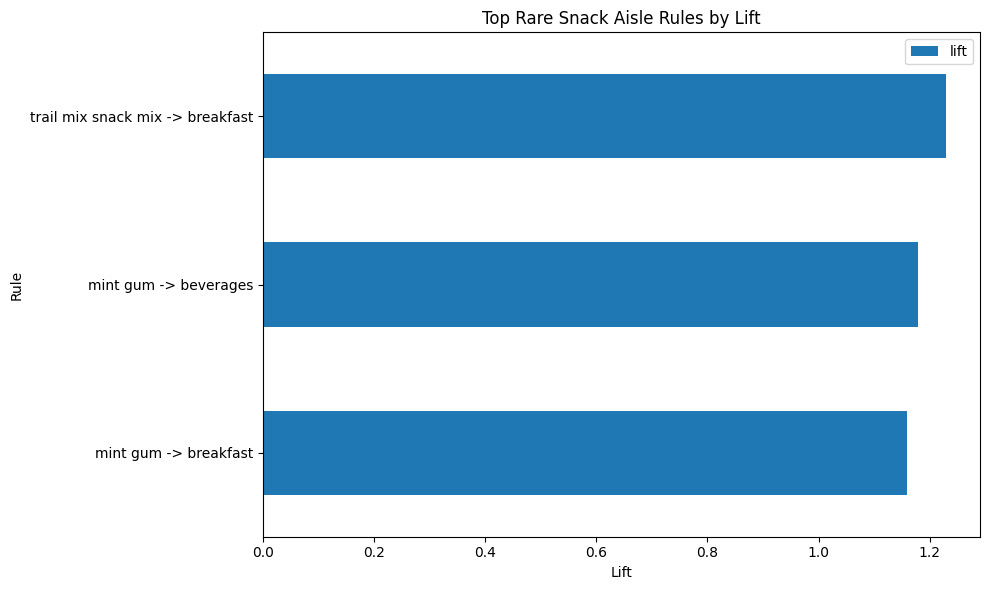

In [77]:
# chart cell
# chart top rare snack rules by lift

top_rare_rules = rare_results.head(10).copy()
top_rare_rules["rule"] = (
    top_rare_rules["antecedent_text"] + " -> " + top_rare_rules["consequent_text"]
)

top_rare_rules = top_rare_rules.sort_values("lift")

top_rare_rules.plot(
    kind="barh",
    x="rule",
    y="lift",
    figsize=(10, 6)
)

plt.title("Top Rare Snack Aisle Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.tight_layout()
plt.show()

# Extra Credit Section: Snack Reorder Loyalty Analysis

In [78]:
# Extra Credit: Snack reorder loyalty analysis
# This section examines reorder behavior for popular snack products. While purchase frequency shows which products are commonly bought, 
# reorder behavior helps show which snack items customers are more likely to buy again, which can indicate stronger product loyalty.

# Merge order-product and product info
reorder_data = order_products_train_df.merge(
    products_df[["product_id", "product_name", "department_id"]],
    on="product_id",
    how="left"
)

# Keep only snack department
reorder_data = reorder_data[reorder_data["department_id"] == 19].copy()

# Find top 10 most purchased snack products
top_10_snack_names = reorder_data["product_name"].value_counts().head(10).index.tolist()

top_10_reorder_data = reorder_data[
    reorder_data["product_name"].isin(top_10_snack_names)
].copy()

# Compute reorder rate for each product
reorder_summary = top_10_reorder_data.groupby("product_name").agg(
    total_purchases=("reordered", "count"),
    total_reordered=("reordered", "sum")
).reset_index()

reorder_summary["reorder_rate"] = (
    reorder_summary["total_reordered"] / reorder_summary["total_purchases"]
)

reorder_summary = reorder_summary.sort_values(
    by="reorder_rate",
    ascending=False
)

reorder_summary["reorder_rate"] = reorder_summary["reorder_rate"].round(3)

display(reorder_summary)

,product_name,total_purchases,total_reordered,reorder_rate
9,Trail Mix,533,419,0.786
5,Original Veggie Straws,684,470,0.687
1,Baked Aged White Cheddar Rice and Corn Puffs,546,356,0.652
3,Lightly Salted Baked Snap Pea Crisps,991,640,0.646
4,Organic Tortilla Chips,637,410,0.644
7,Sea Salt & Vinegar Potato Chips,597,384,0.643
0,100 Calorie Per Bag Popcorn,552,348,0.630
8,Sea Salt Pita Chips,707,440,0.622
6,Pretzel Crisps Original Deli Style Pretzel Cra...,753,462,0.614
2,Chocolate Chip Cookies,614,345,0.562


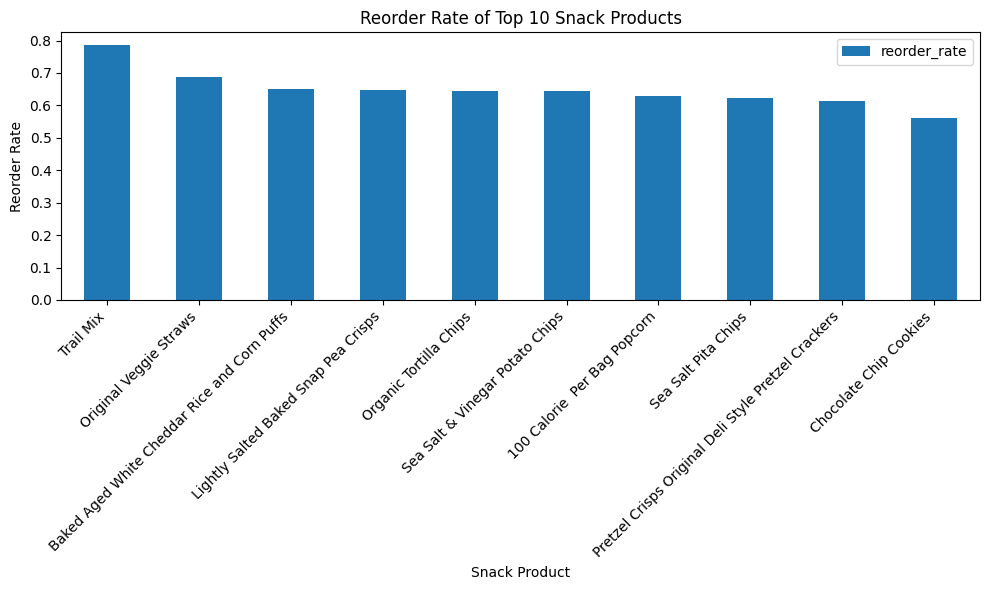

In [79]:
# Bar chart for reorder loyalty

reorder_summary.plot(
    kind="bar",
    x="product_name",
    y="reorder_rate",
    figsize=(10, 6)
)

plt.title("Reorder Rate of Top 10 Snack Products")
plt.xlabel("Snack Product")
plt.ylabel("Reorder Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Key Findings and Conclusion

This project analyzed the Snacks department in the Instacart dataset using both statistical analysis and pattern mining. The statistical results showed that snacks are a major part of customer shopping behavior. About 43.67% of training orders contained at least one snack item, and snack-containing orders averaged about 2.07 snack items per order. In addition, the aisle analysis showed that snack products are concentrated in aisles such as candy chocolate, chips pretzels, cookies cakes, energy granola bars, and crackers.

The pattern mining results also revealed that snack purchases are connected to broader shopping behavior. Cross-department mining showed that snacks were frequently associated with departments such as breakfast, deli, bakery, frozen, and dry goods pasta. Multilevel mining showed relationships across snack department, aisle, and product levels, while multidimensional mining connected snack-related shopping behavior with context such as basket size, time, and day type. Rare pattern mining further identified less common but still meaningful rules, such as snack aisles that appeared with departments like breakfast and beverages.

Overall, the results suggest that snacks are not usually purchased in isolation. Instead, they are often part of larger meal-related, convenience-oriented, or household-oriented shopping trips. This makes the Snacks department a strong candidate for cross-promotion, product recommendation, and basket-based marketing strategies.